# Syllogistic CSD Sampling: Flickering Leading Indicator Test

**Experiment**: 3 Weak LLMs (ministral-3b, llama-3.1-8b, gemini-2.0-flash-lite) tested across 22 difficulty levels (d=2-30) on syllogistic logic tasks with N=50 responses per model-difficulty pair.

**What this does**: Computes a full Critical Slowing Down (CSD) indicator battery including:
- Embedding variance & mean cosine distance
- Hartigan's dip test for bimodality
- Silhouette score (k=2 clustering)
- Bimodality coefficient & Ashman D
- Self-consistency disagreement & answer balance
- Within-chain confidence autocorrelation

Tests whether **flickering** (transient bimodality signals at easy difficulty levels) serves as a **leading indicator** of reasoning collapse before accuracy drops — targeting Success Criterion 1 (SC1).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages used are pre-installed on Colab; install locally to match Colab env
if 'google.colab' not in sys.modules:
    # scipy==1.16.3 requires Python>=3.11 (Colab uses 3.12); use latest compatible locally
    _pip('numpy==2.0.2', 'scipy>=1.13,<2', 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import re
from collections import Counter, defaultdict
from typing import Any

import numpy as np
from scipy.stats import kendalltau, pearsonr, skew, kurtosis
import matplotlib.pyplot as plt
from tabulate import tabulate

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-276cb0-flickering-before-failing-ecological-cri/main/experiment_iter4_syllogistic_csd/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["datasets"][0]["examples"]
metadata = data["metadata"]
print(f"Loaded {len(examples)} CSD entries across {metadata['experiment_config']['n_difficulty_levels']} difficulty levels")
print(f"Models: {metadata['experiment_config']['models']}")
print(f"Difficulty range: d={metadata['difficulty_range'][0]}-{metadata['difficulty_range'][1]}")

Loaded 66 CSD entries across 22 difficulty levels
Models: ['mistralai/ministral-3b-2512', 'meta-llama/llama-3.1-8b-instruct', 'google/gemini-2.0-flash-lite-001']
Difficulty range: d=2-30


## Configuration

Tunable thresholds for CSD analysis. These match the original experiment parameters.

In [5]:
# ── Analysis thresholds ──
ACCURACY_THRESHOLD = 0.8        # High-accuracy cutoff for pre-boundary levels
DIP_P_THRESHOLD = 0.05          # Dip test significance for bimodality
SILHOUETTE_THRESHOLD = 0.3      # Silhouette score threshold for bimodality
BC_THRESHOLD = 5.0 / 9.0        # Bimodality coefficient threshold (~0.556)
SCALING_ALPHA_LOW = -0.7        # Lower bound for CSD scaling exponent
SCALING_ALPHA_HIGH = -0.3       # Upper bound for CSD scaling exponent
SEED = 42

## Parse Data into Per-Model Structures

Reorganize the flat example list into dictionaries keyed by (model, difficulty) for analysis.

In [6]:
# Parse examples into per-model dictionaries
models = metadata["experiment_config"]["models"]
model_tiers = metadata["experiment_config"]["model_tiers"]
difficulties = sorted(set(ex["metadata_difficulty"] for ex in examples))

# Build CSD indicator dicts keyed by (model, difficulty)
csd_by_model: dict[str, dict[int, dict]] = defaultdict(dict)
accuracy_by_model: dict[str, dict[int, float]] = defaultdict(dict)
variance_by_model: dict[str, dict[int, float]] = defaultdict(dict)
dip_by_model: dict[str, dict[int, float]] = defaultdict(dict)
sil_by_model: dict[str, dict[int, float]] = defaultdict(dict)
dis_by_model: dict[str, dict[int, float]] = defaultdict(dict)

for ex in examples:
    model = ex["metadata_model"]
    d = ex["metadata_difficulty"]
    acc = float(ex["predict_accuracy"])
    var_ = float(ex["predict_csd_variance"])
    dip_stat = float(ex["predict_dip_statistic"])
    dip_pval = float(ex["predict_dip_pvalue"])
    sil = float(ex["predict_silhouette_k2"])
    bc = float(ex["predict_bimodality_coefficient"])
    ashman = float(ex["predict_ashman_d"])
    dis = float(ex["predict_disagreement_rate"])
    bal = float(ex["predict_answer_balance"])
    autocorr = float(ex["predict_chain_autocorrelation"])
    consensus = ex["predict_bimodality_consensus"] == "True"

    csd_by_model[model][d] = {
        "accuracy": acc,
        "embedding_variance": var_,
        "dip_statistic": dip_stat,
        "dip_pvalue": dip_pval,
        "silhouette_k2": sil,
        "bimodality_coefficient": bc,
        "ashman_d": ashman,
        "disagreement_rate": dis,
        "answer_balance": bal,
        "chain_autocorrelation": autocorr,
        "bimodality_consensus": consensus,
    }
    accuracy_by_model[model][d] = acc
    variance_by_model[model][d] = var_
    dip_by_model[model][d] = dip_stat
    sil_by_model[model][d] = sil
    dis_by_model[model][d] = dis

print(f"Parsed {len(models)} models x {len(difficulties)} difficulty levels")
for m in models:
    accs = list(accuracy_by_model[m].values())
    print(f"  {m} ({model_tiers[m]}): accuracy {min(accs):.2f}-{max(accs):.2f}")

Parsed 3 models x 22 difficulty levels
  mistralai/ministral-3b-2512 (small): accuracy 0.38-1.00
  meta-llama/llama-3.1-8b-instruct (medium): accuracy 0.52-0.94
  google/gemini-2.0-flash-lite-001 (weak): accuracy 0.92-1.00


## Analysis Functions

Core CSD analysis: find the critical difficulty d* (where accuracy drops below 0.5), fit variance scaling, test flickering as a leading indicator, and compute mixture correlations.

In [7]:
def find_critical_difficulty(accuracy_by_level: dict[int, float]) -> int | None:
    """Find d* = first difficulty where accuracy drops below 0.5."""
    for d in sorted(accuracy_by_level.keys()):
        if accuracy_by_level[d] < 0.5:
            return d
    return None


def fit_variance_scaling(
    difficulties: list[int],
    variances: list[float],
    d_star: int,
) -> dict[str, Any]:
    """Fit log(Var) ~ alpha * log(d* - d) via OLS.

    Only use levels where d < d*. Tests if alpha in [-0.7, -0.3].
    """
    valid = [(d, v) for d, v in zip(difficulties, variances)
             if d < d_star and v > 0]
    if len(valid) < 3:
        return {"alpha": None, "r_squared": None, "consistent_with_fold": None,
                "theoretical_prediction": -0.5}

    ds, vs = zip(*valid)
    log_dist = np.log(np.array([d_star - d for d in ds], dtype=float))
    log_var = np.log(np.array(vs, dtype=float))

    A = np.vstack([log_dist, np.ones(len(log_dist))]).T
    result = np.linalg.lstsq(A, log_var, rcond=None)
    alpha = float(result[0][0])

    ss_res = float(np.sum((log_var - A @ result[0]) ** 2))
    ss_tot = float(np.sum((log_var - log_var.mean()) ** 2))
    r_sq = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

    return {
        "alpha": alpha,
        "r_squared": r_sq,
        "consistent_with_fold": SCALING_ALPHA_LOW <= alpha <= SCALING_ALPHA_HIGH,
        "theoretical_prediction": -0.5,
    }


def test_flickering_leading(
    accuracy_by_level: dict[int, float],
    csd_by_level: dict[int, dict],
    d_star: int | None,
) -> dict[str, Any]:
    """Test flickering leading indicator (SC1 target).

    Check if bimodality signals flicker at levels where accuracy is still high.
    """
    if d_star is None:
        max_d = max(accuracy_by_level.keys()) + 1
    else:
        max_d = d_star

    high_acc_levels = [d for d, a in accuracy_by_level.items()
                       if a > ACCURACY_THRESHOLD and d < max_d]

    if not high_acc_levels:
        return {
            "flickering_dip": False, "flickering_sil": False,
            "flickering_bc": False, "flickering_consensus": False,
            "earliest_flickering_level": None, "lead_time": 0,
            "n_high_acc_levels": 0,
        }

    flicker_dip = flicker_sil = flicker_bc = flicker_consensus = False
    earliest_level = None

    for d in sorted(high_acc_levels):
        csd = csd_by_level.get(d, {})
        if csd.get("dip_pvalue", 1.0) < DIP_P_THRESHOLD:
            flicker_dip = True
            if earliest_level is None: earliest_level = d
        if csd.get("silhouette_k2", 0.0) > SILHOUETTE_THRESHOLD:
            flicker_sil = True
            if earliest_level is None: earliest_level = d
        if csd.get("bimodality_coefficient", 0.0) > BC_THRESHOLD:
            flicker_bc = True
            if earliest_level is None: earliest_level = d
        if csd.get("bimodality_consensus", False):
            flicker_consensus = True
            if earliest_level is None: earliest_level = d

    lead_time = (max_d - earliest_level) if earliest_level is not None else 0

    return {
        "flickering_dip": flicker_dip, "flickering_sil": flicker_sil,
        "flickering_bc": flicker_bc, "flickering_consensus": flicker_consensus,
        "earliest_flickering_level": earliest_level, "lead_time": lead_time,
        "n_high_acc_levels": len(high_acc_levels),
    }


def test_leading_indicator(
    accuracy_by_level: dict[int, float],
    indicator_by_level: dict[int, float],
    d_star: int,
) -> dict[str, Any]:
    """Test whether CSD indicator rises significantly before d* using Kendall tau."""
    pre_boundary = {d: v for d, v in indicator_by_level.items()
                    if d < d_star and accuracy_by_level.get(d, 0) > ACCURACY_THRESHOLD}

    if len(pre_boundary) < 3:
        return {"is_leading": None, "lead_distance": 0, "kendall_tau": None,
                "p_value": None, "levels_tested": len(pre_boundary)}

    sorted_d = sorted(pre_boundary.keys())
    tau, p_value = kendalltau(sorted_d, [pre_boundary[d] for d in sorted_d])

    return {
        "kendall_tau": float(tau), "p_value": float(p_value),
        "is_leading": p_value < 0.05 and tau > 0,
        "lead_distance": d_star - max(sorted_d),
        "levels_tested": len(sorted_d),
        "accuracy_at_last_preboundary": accuracy_by_level.get(max(sorted_d), 0.0),
    }


def compute_mixture_correlation(
    accuracy_by_level: dict[int, float],
    variance_by_level: dict[int, float],
) -> dict[str, Any]:
    """Test whether variance tracks the binomial mixture prediction p(1-p)."""
    common_levels = sorted(set(accuracy_by_level) & set(variance_by_level))
    if len(common_levels) < 4:
        return {"pearson_r": None, "p_value": None, "n_levels": len(common_levels)}

    accs = [accuracy_by_level[d] for d in common_levels]
    vars_ = [variance_by_level[d] for d in common_levels]
    mixture_pred = [p * (1 - p) for p in accs]

    try:
        r, p = pearsonr(mixture_pred, vars_)
        return {"pearson_r": float(r), "p_value": float(p), "n_levels": len(common_levels)}
    except Exception:
        return {"pearson_r": None, "p_value": None, "n_levels": len(common_levels)}

print("Analysis functions defined.")

Analysis functions defined.


## Run CSD Analysis Pipeline

For each model: find the critical difficulty d*, fit variance scaling, test flickering indicators, and compute mixture correlations.

In [8]:
# Run full analysis for each model
analysis = {}
for model_id in models:
    acc_by_level = accuracy_by_model[model_id]
    var_by_level = variance_by_model[model_id]
    model_csd = csd_by_model[model_id]

    d_star = find_critical_difficulty(acc_by_level)
    model_analysis = {"d_star": d_star, "tier": model_tiers[model_id]}

    if d_star is not None:
        model_analysis["scaling"] = fit_variance_scaling(
            list(var_by_level.keys()), list(var_by_level.values()), d_star)
        for name, ind in [("leading_var", variance_by_model[model_id]),
                          ("leading_dip", dip_by_model[model_id]),
                          ("leading_sil", sil_by_model[model_id]),
                          ("leading_dis", dis_by_model[model_id])]:
            model_analysis[name] = test_leading_indicator(acc_by_level, ind, d_star)
    else:
        model_analysis["scaling"] = {"alpha": None, "r_squared": None,
                                     "consistent_with_fold": None, "theoretical_prediction": -0.5}
        for name in ["leading_var", "leading_dip", "leading_sil", "leading_dis"]:
            model_analysis[name] = {"is_leading": None, "lead_distance": 0,
                                    "kendall_tau": None, "p_value": None, "levels_tested": 0}

    model_analysis["flickering"] = test_flickering_leading(acc_by_level, model_csd, d_star)
    model_analysis["mixture_corr"] = compute_mixture_correlation(acc_by_level, var_by_level)
    analysis[model_id] = model_analysis

    # Print summary
    flick = model_analysis["flickering"]
    scaling = model_analysis["scaling"]
    mix = model_analysis["mixture_corr"]
    print(f"\n{'='*60}")
    print(f"Model: {model_id} ({model_analysis['tier']})")
    print(f"  d* (capability boundary): {d_star}")
    print(f"  Scaling alpha: {scaling.get('alpha')}, R2: {scaling.get('r_squared')}")
    print(f"  Flickering dip: {flick['flickering_dip']}, sil: {flick['flickering_sil']}, "
          f"bc: {flick['flickering_bc']}, consensus: {flick['flickering_consensus']}")
    print(f"  Earliest flickering: d={flick['earliest_flickering_level']}, "
          f"lead_time={flick['lead_time']}")
    print(f"  Mixture correlation: r={mix.get('pearson_r')}, p={mix.get('p_value')}")


Model: mistralai/ministral-3b-2512 (small)
  d* (capability boundary): 22
  Scaling alpha: 0.046009008746363246, R2: 0.08210820491649895
  Flickering dip: True, sil: False, bc: True, consensus: True
  Earliest flickering: d=2, lead_time=20
  Mixture correlation: r=-0.18651919300122802, p=0.4059081063735147

Model: meta-llama/llama-3.1-8b-instruct (medium)
  d* (capability boundary): None
  Scaling alpha: None, R2: None
  Flickering dip: True, sil: False, bc: True, consensus: True
  Earliest flickering: d=2, lead_time=29
  Mixture correlation: r=-0.21133185647817776, p=0.34512025986406636

Model: google/gemini-2.0-flash-lite-001 (weak)
  d* (capability boundary): None
  Scaling alpha: None, R2: None
  Flickering dip: True, sil: True, bc: True, consensus: True
  Earliest flickering: d=2, lead_time=29
  Mixture correlation: r=-0.2992847598031375, p=0.17602807247682178


## SC1 Results Summary

Summary table of flickering detection results across all models — the core Success Criterion 1 test.

In [9]:
# Build SC1 results table
table_rows = []
for model_id in models:
    a = analysis[model_id]
    flick = a["flickering"]
    short_name = model_id.split("/")[-1]
    table_rows.append([
        short_name,
        a["tier"],
        a["d_star"] or "N/A",
        "Y" if flick["flickering_dip"] else "N",
        "Y" if flick["flickering_sil"] else "N",
        "Y" if flick["flickering_bc"] else "N",
        "Y" if flick["flickering_consensus"] else "N",
        flick["earliest_flickering_level"] or "N/A",
        flick["lead_time"],
        flick["n_high_acc_levels"],
    ])

headers = ["Model", "Tier", "d*", "Dip", "Sil", "BC", "Consensus",
           "Earliest", "Lead", "HiAcc Lvls"]
print("SC1 Flickering Leading Indicator Results:")
print(tabulate(table_rows, headers=headers, tablefmt="grid"))

any_flickering = any(analysis[m]["flickering"]["flickering_consensus"] for m in models)
print(f"\nSC1 verdict: Flickering detected = {any_flickering}")

SC1 Flickering Leading Indicator Results:
+---------------------------+--------+------+-------+-------+------+-------------+------------+--------+--------------+
| Model                     | Tier   | d*   | Dip   | Sil   | BC   | Consensus   |   Earliest |   Lead |   HiAcc Lvls |
+===========================+========+======+=======+=======+======+=============+============+========+==============+
| ministral-3b-2512         | small  | 22   | Y     | N     | Y    | Y           |          2 |     20 |           14 |
+---------------------------+--------+------+-------+-------+------+-------------+------------+--------+--------------+
| llama-3.1-8b-instruct     | medium | N/A  | Y     | N     | Y    | Y           |          2 |     29 |            8 |
+---------------------------+--------+------+-------+-------+------+-------------+------------+--------+--------------+
| gemini-2.0-flash-lite-001 | weak   | N/A  | Y     | Y     | Y    | Y           |          2 |     29 |           22 

## Visualization

Multi-panel plots showing how CSD indicators evolve across difficulty levels for each model. Key pattern: bimodality indicators "flicker" at easy difficulty levels (high accuracy) before reasoning collapse occurs.

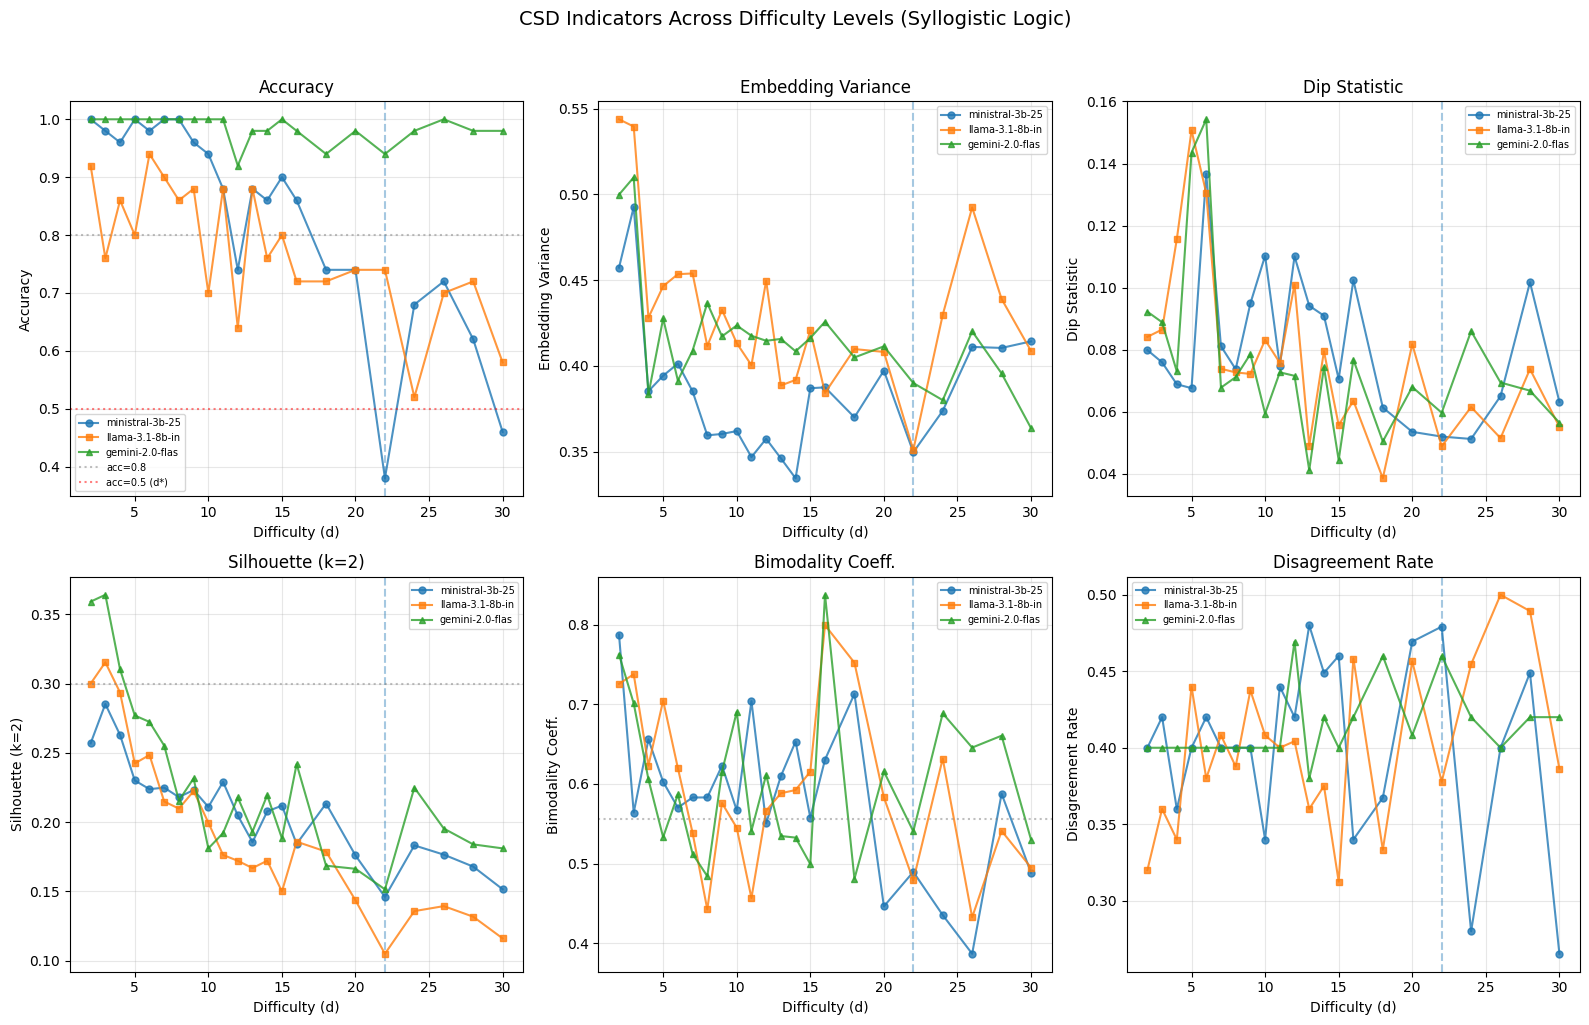

Saved csd_indicators.png


In [10]:
colors = {"small": "#1f77b4", "medium": "#ff7f0e", "weak": "#2ca02c"}
markers = {"small": "o", "medium": "s", "weak": "^"}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("CSD Indicators Across Difficulty Levels (Syllogistic Logic)", fontsize=14, y=1.02)

indicator_panels = [
    ("accuracy", "Accuracy", axes[0, 0]),
    ("embedding_variance", "Embedding Variance", axes[0, 1]),
    ("dip_statistic", "Dip Statistic", axes[0, 2]),
    ("silhouette_k2", "Silhouette (k=2)", axes[1, 0]),
    ("bimodality_coefficient", "Bimodality Coeff.", axes[1, 1]),
    ("disagreement_rate", "Disagreement Rate", axes[1, 2]),
]

for key, title, ax in indicator_panels:
    for model_id in models:
        tier = model_tiers[model_id]
        short = model_id.split("/")[-1][:15]
        ds = sorted(csd_by_model[model_id].keys())
        vals = [csd_by_model[model_id][d][key] for d in ds]
        ax.plot(ds, vals, marker=markers[tier], color=colors[tier],
                label=short, markersize=5, linewidth=1.5, alpha=0.8)

        # Mark d* if exists
        d_star = analysis[model_id]["d_star"]
        if d_star is not None:
            ax.axvline(x=d_star, color=colors[tier], linestyle="--", alpha=0.4)

    # Add threshold lines where relevant
    if key == "accuracy":
        ax.axhline(y=ACCURACY_THRESHOLD, color="gray", linestyle=":", alpha=0.5, label="acc=0.8")
        ax.axhline(y=0.5, color="red", linestyle=":", alpha=0.5, label="acc=0.5 (d*)")
    elif key == "silhouette_k2":
        ax.axhline(y=SILHOUETTE_THRESHOLD, color="gray", linestyle=":", alpha=0.5)
    elif key == "bimodality_coefficient":
        ax.axhline(y=BC_THRESHOLD, color="gray", linestyle=":", alpha=0.5)

    ax.set_title(title)
    ax.set_xlabel("Difficulty (d)")
    ax.set_ylabel(title)
    ax.legend(fontsize=7, loc="best")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("csd_indicators.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved csd_indicators.png")

## Flickering Heatmap

Visualize where bimodality consensus fires across models and difficulty levels. Green cells = flickering detected while accuracy is still high (leading indicator).

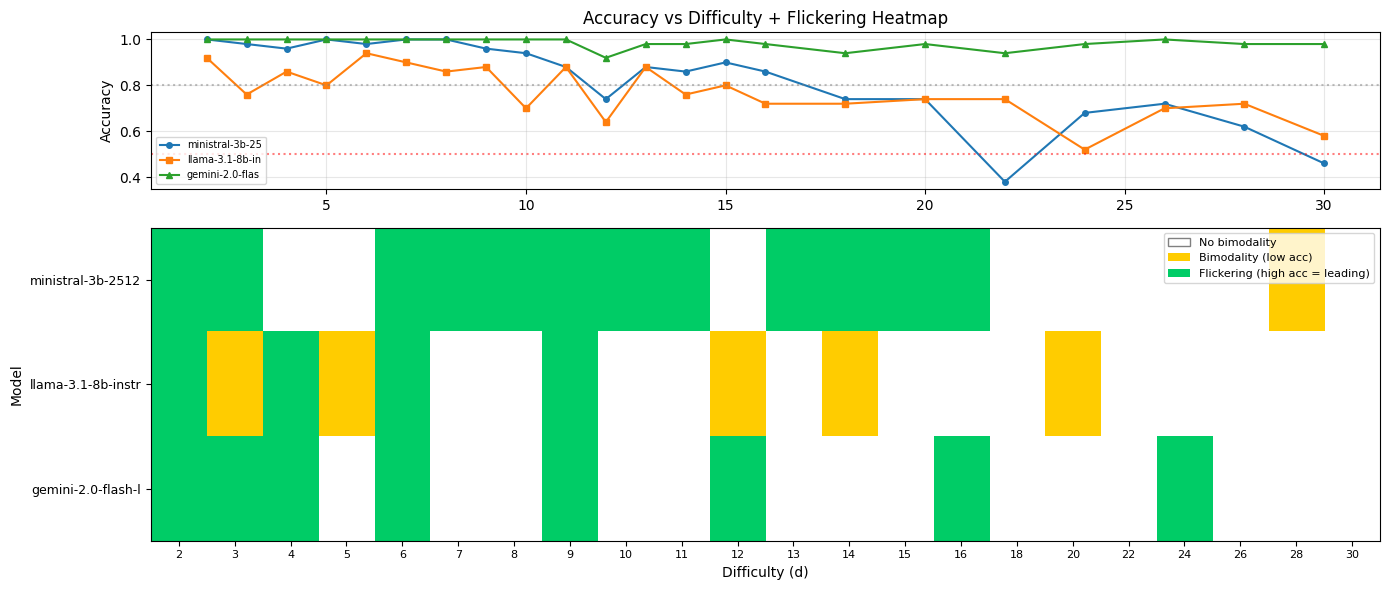

Saved flickering_heatmap.png


In [11]:
# Build flickering heatmap data
short_names = [m.split("/")[-1][:18] for m in models]
heatmap = np.zeros((len(models), len(difficulties)))

for i, model_id in enumerate(models):
    d_star = analysis[model_id]["d_star"]
    max_d = d_star if d_star is not None else max(difficulties) + 1
    for j, d in enumerate(difficulties):
        csd = csd_by_model[model_id].get(d, {})
        acc = accuracy_by_model[model_id].get(d, 0)
        consensus = csd.get("bimodality_consensus", False)
        if consensus and acc > ACCURACY_THRESHOLD and d < max_d:
            heatmap[i, j] = 2  # flickering while high-accuracy (leading!)
        elif consensus:
            heatmap[i, j] = 1  # bimodality but low accuracy
        else:
            heatmap[i, j] = 0  # no bimodality

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), gridspec_kw={"height_ratios": [1, 2]})

# Top: accuracy curves
for model_id in models:
    tier = model_tiers[model_id]
    short = model_id.split("/")[-1][:15]
    ds = sorted(accuracy_by_model[model_id].keys())
    accs = [accuracy_by_model[model_id][d] for d in ds]
    ax1.plot(ds, accs, marker=markers[tier], color=colors[tier],
             label=short, markersize=4, linewidth=1.5)
ax1.axhline(y=ACCURACY_THRESHOLD, color="gray", linestyle=":", alpha=0.5)
ax1.axhline(y=0.5, color="red", linestyle=":", alpha=0.5)
ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy vs Difficulty + Flickering Heatmap")
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3)

# Bottom: heatmap
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["white", "#ffcc00", "#00cc66"])
im = ax2.imshow(heatmap, aspect="auto", cmap=cmap, vmin=0, vmax=2)
ax2.set_yticks(range(len(models)))
ax2.set_yticklabels(short_names, fontsize=9)
ax2.set_xticks(range(len(difficulties)))
ax2.set_xticklabels(difficulties, fontsize=8)
ax2.set_xlabel("Difficulty (d)")
ax2.set_ylabel("Model")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="white", edgecolor="gray", label="No bimodality"),
    Patch(facecolor="#ffcc00", label="Bimodality (low acc)"),
    Patch(facecolor="#00cc66", label="Flickering (high acc = leading)"),
]
ax2.legend(handles=legend_elements, loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("flickering_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved flickering_heatmap.png")